In [2]:
import numpy as np
import torch
import pickle
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm
import os
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output
import wandb
import psutil
import GPUtil
from functools import partial
import gc
import copy
wandb.login(key="a338f755915cccd861b14f29bf68601d8e1ec2c9")

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN
from bioplnn.datasets import Mazes

from bioplnn.utils import (
    initialize_criterion,
    initialize_dataloader,
    initialize_model,
    initialize_optimizer,
    initialize_scheduler,
    manual_seed,
    manual_seed_deterministic,
    pass_fn,
)

maze_data_path = "/om2/vast/evlab/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/om2/vast/evlab/jackking/torch-bioplnn-dev/train/checkpoints/"
model_csv_path = "/om2/vast/evlab/jackking/torch-bioplnn-dev/train/models.csv"
model_configs_path = "/om2/vast/evlab/jackking/torch-bioplnn-dev/train/model_configs.json"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

BATCH_SIZE = 32

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64, 256, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(256, 512, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(512 * 6 * 6, 1024)
        self.fc2 = nn.Linear(1024, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, num_steps=None):  # num_steps parameter for compatibility
        # x shape: [batch_size, channels, height, width]
        x = self.pool(self.relu(self.conv1(x)))  # -> [batch_size, 32, 24, 24]
        x = self.pool(self.relu(self.conv2(x)))  # -> [batch_size, 64, 12, 12]
        x = self.pool(self.relu(self.conv3(x)))  # -> [batch_size, 128, 6, 6]
        x = x.view(-1, 512 * 6 * 6)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def load_data(batch_size=BATCH_SIZE, num_samples=None):

    # Get the data loaders
    train_loader, test_loader = initialize_dataloader(
        seed=42, root="./data/mazes/", batch_size=batch_size, dataset="mazes"
    )

    return train_loader, test_loader

# Define evaluation function
def evaluate(model, data_loader, criterion, device, num_steps):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, labels in data_loader:
            x = x.to(device)
            labels = labels.to(device)
            
            logits = model(x, num_steps=num_steps)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    return avg_loss, accuracy

def get_gpu_memory():
    """Get current GPU memory usage in MB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024**2
    return 0

def get_cpu_memory():
    """Get current CPU memory usage in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**2

def get_gpu_utilization():
    """Get current GPU utilization percentage."""
    if torch.cuda.is_available():
        try:
            gpus = GPUtil.getGPUs()
            if gpus:
                return gpus[0].load * 100
        except:
            pass
    return 0

def init_weights_kaiming(m, nonlinearity="relu"):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity=nonlinearity)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def init_weights_zero(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def get_class_distribution(data_loader):
    """Calculate class distribution in the dataset."""
    class_counts = torch.zeros(2)  # Assuming binary classification
    total_samples = 0
    
    for _, labels in data_loader:
        for label in labels:
            class_counts[label] += 1
        total_samples += len(labels)
    
    return class_counts / total_samples

def get_gradient_norm(model):
    """Calculate the L2 norm of gradients for all parameters."""
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

def analyze_logits(logits, labels, num_samples=5, detailed=False):
    """Analyze logits distribution and predictions."""
    probs = torch.softmax(logits, dim=1)
    _, predicted = torch.max(logits, 1)
    
    # Get random samples
    indices = torch.randperm(len(logits))[:num_samples]
    
    print("\nLogits Analysis:")
    print("=" * 50)
    for idx in indices:
        print(f"Sample {idx}:")
        print(f"True label: {labels[idx].item()}")
        print(f"Predicted: {predicted[idx].item()}")
        print(f"Logits: {logits[idx].detach().cpu().numpy()}")
        print(f"Probabilities: {probs[idx].detach().cpu().numpy()}")
        print("-" * 30)
    
    if detailed:
        # Additional statistics
        logits_np = logits.detach().cpu().numpy()
        probs_np = probs.detach().cpu().numpy()
        print("\nDetailed Statistics:")
        print(f"Logits mean: {logits_np.mean():.4f}, std: {logits_np.std():.4f}")
        print(f"Logits min: {logits_np.min():.4f}, max: {logits_np.max():.4f}")
        print(f"Probabilities mean: {probs_np.mean():.4f}, std: {probs_np.std():.4f}")
        print(f"Probabilities min: {probs_np.min():.4f}, max: {probs_np.max():.4f}")
        
        # Distribution of predictions
        unique, counts = np.unique(predicted.cpu().numpy(), return_counts=True)
        pred_dist = dict(zip(unique, counts))
        print(f"Prediction distribution: {pred_dist}")

def train(model, train_loader, test_loader, criterion, optimizer, scheduler, num_steps, max_epochs, max_gradient, train_log_frequency, wandb_name, run):
    # Define the training loop
    model.train()

    # Print initial diagnostics
    print("\nInitial Dataset Analysis:")
    print("=" * 50)
    train_dist = get_class_distribution(train_loader)
    test_dist = get_class_distribution(test_loader)
    print(f"Training set class distribution: {train_dist.numpy()}")
    print(f"Test set class distribution: {test_dist.numpy()}")
    print("=" * 50)

    gpu_memory = get_gpu_memory()
    cpu_memory = get_cpu_memory()
    gpu_util = get_gpu_utilization()
    print(f"GPU Memory: {gpu_memory:.1f}MB | CPU Memory: {cpu_memory:.1f}MB | GPU Utilization: {gpu_util:.1f}%")

    val_accs = []
    patience = 30

    save_path = f"{checkpoint_path}/{wandb_name}"
    os.makedirs(save_path, exist_ok=True)
    
    for epoch in range(max_epochs):
        run.config.update({"n_epochs": epoch}, allow_val_change=True)
        running_loss, running_correct, running_total = 0, 0, 0
        for i, (x, labels) in enumerate(tqdm(train_loader)):
            try:
                x = x.to(device)
            except AttributeError:
                x = [t.to(device) for t in x]
            labels = labels.to(device)
            
            # Forward pass
            logits = model(x, num_steps=num_steps, loss_all_timesteps=False)
            loss = criterion(logits, labels)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # Gradient analysis
            grad_norm = get_gradient_norm(model)

            # Gradient clipping
            if max_gradient is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_gradient)
            
            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            # Calculate batch metrics
            predicted = torch.argmax(logits, 1)
            batch_total = labels.size(0)
            batch_correct = (predicted == labels).sum().item()
            batch_loss = loss.item()

            # Update running metrics
            running_total += batch_total
            running_correct += batch_correct
            running_loss += batch_loss * batch_total  # Weight loss by batch size

            # Log batch metrics if needed
            if i % train_log_frequency == 0:
                batch_acc = batch_correct / batch_total
                print(
                    f"Batch {i} | "
                    + f"Loss: {batch_loss:.4f} | "
                    + f"Acc: {batch_acc:.2%} | "
                    + f"Grad Norm: {grad_norm:.4f} | "
                    + f"LR: {optimizer.param_groups[0]['lr']:.2e}"
                )
                
                # Analyze logits every train_log_frequency batches
                # Use detailed analysis for first few batches
                # analyze_logits(logits, labels, detailed=(i < 3))

                wandb.log({
                    "train_loss": running_loss / running_total,
                    "train_acc": running_correct / running_total,
                    "gradient_norm": grad_norm,
                    "step": epoch * len(train_loader) + i,
                    "lr": optimizer.param_groups[0]["lr"]
                })
        
        # Calculate epoch metrics
        epoch_loss = running_loss / running_total
        epoch_acc = running_correct / running_total
        
        print(
            f"Training | Epoch: {epoch} | "
            + f"Loss: {epoch_loss:.4f} | "
            + f"Acc: {epoch_acc:.2%} | "
            + f"GPU Memory: {get_gpu_memory():.1f}MB | "
            + f"CPU Memory: {get_cpu_memory():.1f}MB"
        )

        # Evaluate on validation set
        val_loss, val_acc = evaluate(model, test_loader, criterion, device, num_steps)
        model.train()
        
        wandb.log({
            "epoch": epoch,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })
        
        if epoch % 10 == 0:
            # Save model 
            sd = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            torch.save(sd, f"{save_path}/{epoch}.pth")
        
        val_accs.append(val_acc)
        
        if len(val_accs) > patience+10:
            best_val_acc = max(val_accs[:-patience])
            if all(acc <= best_val_acc for acc in val_accs[-patience:]):
                print("Validation accuracy not improving, stopping training")
                print(f"Best validation accuracy: {best_val_acc:.2%}")
                print(val_accs[-patience:])
                # break

def get_scheduler(scheduler):

    if not scheduler == None:

        kwargs = scheduler["kwargs"].copy()

        if "Cycle" in scheduler["name"]:
            kwargs["max_lr"] = lr
            kwargs["total_steps"] = len(train_loader) * max_epochs
        elif "Lambda" in scheduler["name"]:
            warmup_steps = len(train_loader) * scheduler["warmup_epochs"]
            kwargs["lr_lambda"] = lambda step: (step + 1) / warmup_steps if step < warmup_steps else 1.0

        scheduler = initialize_scheduler(
            class_name=scheduler["name"],
            optimizer=optimizer,
            **kwargs)
        return scheduler
    else:
        return None


def run_experiment(model_type, model_config, hyperparams):
    """Run a single experiment with the given model type, config and hyperparameters."""
    # Create the model
    if not model_type == "cnn":
        model = SpatiallyEmbeddedClassifier(**model_config).to(device)
    elif model_type == "cnn":
        model = SimpleCNN(**model_config).to(device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")
    
    # Wrap for multi‑GPU if available
    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
    
    # Extract hyperparameters
    lr = hyperparams.get("lr", 0.001)
    num_samples = hyperparams.get("num_samples", 100)
    num_steps = hyperparams.get("num_steps", 60)
    max_epochs = hyperparams.get("max_epochs", 10)
    batch_size = hyperparams.get("batch_size", 128)
    max_gradient = hyperparams.get("max_gradient", None)
    
    # Define the optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999))
    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    train_loader, test_loader = load_data(batch_size=batch_size, num_samples=num_samples)

    train_log_frequency = max(1, len(train_loader) // 10)  # How often to log training metrics
        
    full_config = {
            "model_type": model_type,
            "model_config": model_config,
            **hyperparams,
        }

    if hyperparams.get("init_weights", "kaiming") == "kaiming":
        model.apply(partial(init_weights_kaiming, nonlinearity=hyperparams.get("neuron_type_nonlinearity", "relu")))
    elif hyperparams.get("init_weights", "kaiming") == "zero":
        model.apply(init_weights_zero)
    
    scheduler = get_scheduler(hyperparams.get("scheduler", None))

    run = wandb.init(
        project="mazes",  # Specify your project
        config=full_config,
    )
    wandb_name = run.name

    #save model config
    with open(checkpoint_path + f"{wandb_name}.pkl", "wb") as f:
        pickle.dump(full_config, f)
    
    train(model, train_loader, test_loader, criterion, optimizer, scheduler, num_steps, max_epochs, max_gradient, train_log_frequency, wandb_name, run)
    
    # Evaluate final performance
    final_val_loss, final_val_acc = evaluate(model, test_loader, criterion, device, num_steps)
    wandb.log({
        "final_val_loss": final_val_loss,
        "final_val_acc": final_val_acc,
    })

    hyperparams["wandb_name"] = wandb_name
    hyperparams["model_type"] = model_type
    #add hyperparams to model_csv
    models_csv = pd.read_csv(model_csv_path)
    models_csv = pd.concat([models_csv, pd.DataFrame([hyperparams])], ignore_index=True)
    models_csv.to_csv(model_csv_path, index=False)
    
    wandb.finish()
    
    return final_val_loss, final_val_acc

def run_sweep(sweep_config):
    """Run a sweep of experiments with different hyperparameters."""
    results = []
    
    # Extract sweep parameters
    model_types = sweep_config.get("model_types", ["bioplnn"])
    # Define base model configs
    base_model_configs = {  #TODO: make these a bunch of yaml files in the model_configs folder
            "1e1i1a": {
                "rnn_kwargs": {
                    "num_areas": 1,
                    "area_kwargs": [
                        {
                            "num_neuron_types": 2,
                            "num_neuron_subtypes": np.array([32, 8]),
                            "neuron_type_class": np.array(["excitatory", "inhibitory"]),
                            "inter_neuron_type_connectivity": np.array(
                                [[1, 1, 0], [1, 1, 1], [1, 0, 0]]
                            ),
                            "in_size": [48, 48],
                            "in_channels": 4,
                            "out_channels": 32,
                            "inter_neuron_type_nonlinearity": np.array([[None, None, None], [None, None, None], [None, None, None]]),
                            "inter_neuron_type_spatial_extents": (5,5),
                        },
                    ],
                },
                "num_classes": 2,
                "fc_dim": 512,
                "dropout": 0.2,
            },
            "hybrid": {
                "rnn_kwargs": {
                    "num_areas": 1,
                    "area_kwargs": [
                        {
                            "num_neuron_types": 1,
                            "num_neuron_subtypes": np.array([64]),
                            "neuron_type_class": np.array(["hybrid"]),
                            "inter_neuron_type_connectivity": np.array(
                                [[1, 0], [1, 1]]
                            ),
                            "in_size": [48, 48],
                            "in_channels": 4,
                            "out_channels": 16,
                            "inter_neuron_type_nonlinearity": np.array([["relu", "relu"], ["relu", "relu"]]),
                            "inter_neuron_type_spatial_extents": (3, 3)
                        },
                    ],
                },
                "num_classes": 2,
                "fc_dim": 64,
                "dropout": 0.1,
            },
            "1h1a": {
                "rnn_kwargs": {
                    "num_areas": 1,
                    "area_kwargs": [
                        {
                            "num_neuron_types": 1,
                            "num_neuron_subtypes": np.array([16]),
                            "neuron_type_class": np.array(["hybrid"]),
                            "inter_neuron_type_connectivity": np.array(
                                [[1, 0], [1, 1]]
                            ),
                            "in_size": [48, 48],
                            "in_channels": 4,
                            "out_channels": 32,
                            "inter_neuron_type_nonlinearity": np.array([["sigmoid", "sigmoid"], ["sigmoid", "sigmoid"]]),
                            "inter_neuron_type_spatial_extents": (3, 3)
                        },
                    ],
                },
                "num_classes": 2,
                "fc_dim": 64,
                "dropout": 0.2,
            },
            "hybrid_ei": {
                "rnn_kwargs": {
                    "num_areas": 1,
                    "area_kwargs": [
                        {
                            "num_neuron_types": 2,
                            "num_neuron_subtypes": np.array([64, 64]),
                            "neuron_type_class": np.array(["hybrid", "hybrid"]),
                            "inter_neuron_type_connectivity": np.array(
                                [[1, 1, 0], [1, 1, 1], [1, 1, 0]]
                            ),
                            "in_size": [48, 48],
                            "in_channels": 4,
                            "out_channels": 16,
                            "inter_neuron_type_nonlinearity": np.array([["relu", "relu", "relu"], ["relu", "relu", "relu"], ["relu", "relu", "relu"]]),
                            "inter_neuron_type_spatial_extents": (3, 3)
                        },
                    ],
                },
                "num_classes": 2,
                "fc_dim": 64,
                "dropout": 0.1,
            },
            "bio_cnn_hybrid": {
                "rnn_kwargs": {
                    "num_areas": 2,
                    "area_kwargs": [
                        {
                            "num_neuron_types": 1,
                            "num_neuron_subtypes": np.array([64]),
                            "neuron_type_class": np.array(["hybrid"]),
                            "inter_neuron_type_connectivity": np.array(
                                [[1, 0], [0, 1]]
                            ),
                            "in_size": [48, 48],
                            "in_channels": 4,
                            "out_channels": 128,
                            "inter_neuron_type_nonlinearity": np.array([["relu", "relu"], ["relu", "relu"]]),
                            "inter_neuron_type_spatial_extents": (5, 5)
                        },
                        {
                            "num_neuron_types": 1,
                            "num_neuron_subtypes": np.array([256]),
                            "neuron_type_class": np.array(["hybrid"]),
                            "inter_neuron_type_connectivity": np.array(
                                [[1, 0], [0, 1]]
                            ),
                            "in_size": [48, 48],
                            "in_channels": 128,
                            "out_channels": 256,
                            "inter_neuron_type_nonlinearity": np.array([["relu", "relu"], ["relu", "relu"]]),
                            "inter_neuron_type_spatial_extents": (5, 5)
                        },
                    ],
                },
                "num_classes": 2,
                "fc_dim": 512,
                "dropout": 0.1,
            },
            "cnn": {
                "in_channels": 4,
                "num_classes": 2,
                "dropout": 0.2,
            }
        }

    # Generate hyperparameter combinations
    hyperparams_list = []
    
    # Helper function to generate all combinations of hyperparameters
    def generate_combinations(params_dict, current_combo=None, keys=None):
        if current_combo is None:
            current_combo = {}
            keys = list(params_dict.keys())
        
        if not keys:
            return [current_combo]
        
        combinations = []
        key = keys[0]
        values = params_dict[key]
        
        for value in values:
            new_combo = current_combo.copy()
            new_combo[key] = value
            combinations.extend(generate_combinations(
                params_dict, new_combo, keys[1:]
            ))
        
        return combinations
    
    # Generate all hyperparameter combinations
    if "hyperparams" in sweep_config:
        hyperparams_list = generate_combinations(sweep_config["hyperparams"])
    else:
        # Default hyperparameters if none specified
        hyperparams_list = [{
            "lr": 0.001,
            "num_samples": 100,
            "num_steps": 60,
            "max_epochs": 10,
            "batch_size": 128,
        }]
    
    # Run experiments for all combinations
    for model_type in model_types:
        for hyperparams in hyperparams_list:
            print(f"\nRunning experiment with model_type={model_type}, hyperparams={hyperparams}")
            
            # Create a copy of the base model config
            model_config = copy.deepcopy(base_model_configs[model_type])
            
            # Apply model-specific hyperparameters
            if not model_type == "cnn":
                # Handle fc_dim
                if "fc_dim" in hyperparams:
                    model_config["fc_dim"] = hyperparams["fc_dim"]
                
                if "num_neuron_types" in hyperparams:
                    model_config["rnn_kwargs"]["area_kwargs"][0]["num_neuron_types"] = hyperparams["num_neuron_types"]
                num_neuron_types = model_config["rnn_kwargs"]["area_kwargs"][0]["num_neuron_types"]
                
                # Handle num_neuron_subtypes
                if "num_neuron_subtypes" in hyperparams:
                    # Convert to numpy array with 2 elements (for excitatory and inhibitory)
                    subtypes_value = hyperparams["num_neuron_subtypes"]
                    if isinstance(subtypes_value, int):
                        # If a single integer is provided, use it for both types
                        model_config["rnn_kwargs"]["area_kwargs"][0]["num_neuron_subtypes"] = np.ones(num_neuron_types, dtype=int) * subtypes_value
                    elif isinstance(subtypes_value, (list, tuple)) and len(subtypes_value) == num_neuron_types:
                        # If a list/tuple of 2 values is provided, use them directly
                        model_config["rnn_kwargs"]["area_kwargs"][0]["num_neuron_subtypes"] = np.array(subtypes_value)

                # Handle inter_neuron_type_connectivity
                if "inter_neuron_type_connectivity" in hyperparams:
                    model_config["rnn_kwargs"]["area_kwargs"][0]["inter_neuron_type_connectivity"] = np.array(hyperparams["inter_neuron_type_connectivity"])
                
                # Handle out_channels
                if "out_channels" in hyperparams:
                    model_config["rnn_kwargs"]["area_kwargs"][0]["out_channels"] = hyperparams["out_channels"]
                
                # Handle inter_neuron_type_spatial_extents
                if "inter_neuron_type_spatial_extents" in hyperparams:
                    if hyperparams["inter_neuron_type_spatial_extents"] == "center_excitation":
                        model_config["rnn_kwargs"]["area_kwargs"][0]["inter_neuron_type_spatial_extents"] = np.array([[(5,5), (5,5), (5,5)], [(3,3), (3,3), (3,3)], [(7,7), (7,7), (7,7)]])
                    elif hyperparams["inter_neuron_type_spatial_extents"] == "center_inhibition":
                        model_config["rnn_kwargs"]["area_kwargs"][0]["inter_neuron_type_spatial_extents"] = np.array([[(5,5), (5,5), (5,5)], [(5,5), (5,5), (5,5)], [(3,3), (5,5), (5,5)]])
                    else:
                        model_config["rnn_kwargs"]["area_kwargs"][0]["inter_neuron_type_spatial_extents"] = hyperparams["inter_neuron_type_spatial_extents"]
                                
                # Handle nonlinearity
                if "inter_neuron_type_nonlinearity" in hyperparams:
                    # Get the connectivity matrix shape
                    connectivity = model_config["rnn_kwargs"]["area_kwargs"][0]["inter_neuron_type_connectivity"]
                    rows, cols = connectivity.shape
                    # Create a matrix of the same shape filled with the chosen nonlinearity
                    nonlinearity_matrix = np.full((rows, cols), hyperparams["inter_neuron_type_nonlinearity"])
                    model_config["rnn_kwargs"]["area_kwargs"][0]["inter_neuron_type_nonlinearity"] = nonlinearity_matrix
                
                if "neuron_type_nonlinearity" in hyperparams:
                    model_config["rnn_kwargs"]["area_kwargs"][0]["neuron_type_nonlinearity"] = hyperparams["neuron_type_nonlinearity"]
                        
            elif model_type == "cnn":
                # Apply any CNN-specific hyperparameters
                if "fc_dim" in hyperparams:
                    # For CNN, we might ignore fc_dim or adapt it somehow
                    pass
            
            # Apply any other model config overrides from sweep_config
            if "model_configs" in sweep_config and model_type in sweep_config["model_configs"]:
                # Deep update the nested dictionary
                def update_dict(d, u):
                    for k, v in u.items():
                        if isinstance(v, dict) and k in d and isinstance(d[k], dict):
                            update_dict(d[k], v)
                        else:
                            d[k] = v
                
                update_dict(model_config, sweep_config["model_configs"][model_type])

            
            try:
                val_loss, val_acc = run_experiment(
                    model_type=model_type,
                    model_config=model_config,
                    hyperparams=hyperparams
                )
                
                # Store results
                results.append({
                    "model_type": model_type,
                    "model_config": model_config,
                    "hyperparams": hyperparams,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                })

                print(f"Experiment completed: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
                
            except Exception as e:
                print(f"Error in experiment: {e}")
                import traceback
                traceback.print_exc()
                wandb.finish()
    
    # Find best model
    if results:
        best_result = max(results, key=lambda x: x["val_acc"])
        print("\n" + "="*50)
        print(f"Best model: {best_result['model_type']}")
        print(f"Best hyperparameters: {best_result['hyperparams']}")
        print(f"Validation accuracy: {best_result['val_acc']:.4f}")
        print(f"Validation loss: {best_result['val_loss']:.4f}")
        print("="*50)
    
    return results

def run_from_checkpoint(wandb_name, epoch, new_params={}):
    full_config = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
    for param, value in new_params.items():
        full_config[param] = value

    model_config = full_config["model_config"]
    num_steps = full_config["num_steps"]
    model = SpatiallyEmbeddedClassifier(**model_config).to(device)
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{epoch}.pth")
    model.load_state_dict(state_dict)
    del state_dict
    gc.collect()
    torch.cuda.empty_cache()
    
    # Extract hyperparameters
    lr = full_config.get("lr", 0.001)
    num_samples = full_config.get("num_samples", 100)
    num_steps = full_config.get("num_steps", 60)
    max_epochs = full_config.get("max_epochs", 10)
    batch_size = full_config.get("batch_size", 128)
    scheduler = get_scheduler(full_config.get("scheduler", None))
    max_gradient = full_config.get("max_gradient", None)
    
    # Define the optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.999))
    # Define the loss function
    criterion = nn.CrossEntropyLoss()

    train_loader, test_loader = load_data(batch_size=batch_size, num_samples=num_samples)

    train_log_frequency = max(1, len(train_loader) // 10)  # How often to log training metrics
    
    run = wandb.init(
        project="mazes",  # Specify your project
        config=full_config,
    )

    wandb_name = run.name
    #save model config
    with open(checkpoint_path + f"{wandb_name}.pkl", "wb") as f:
        pickle.dump(full_config, f)
    model, train_loader, test_loader, criterion, optimizer, scheduler, num_steps, max_epochs, max_gradient, train_log_frequency, wandb_name, run
    train(model, train_loader, test_loader, criterion, optimizer, scheduler, num_steps, max_epochs, max_gradient, train_log_frequency, wandb_name, run)
    
    # Evaluate final performance
    final_val_loss, final_val_acc = evaluate(model, test_loader, criterion, device, num_steps)
    wandb.log({
        "final_val_loss": final_val_loss,
        "final_val_acc": final_val_acc,
    })
    
    wandb.finish()
    
    return final_val_loss, final_val_acc

if __name__ == "__main__":
    print("Running sweep...")

    # OnceCycleLR
        # {"name": "OneCycleLR", "kwargs": {"pct_start": 0.15, "anneal_strategy": 'cos', "div_factor": 15}}
    #LambdaLR
        # {"name": "LambdaLR", "warmup_epochs": 50, "kwargs": {}}
    
    # Define sweep configuration``
    sweep_config = {
        "model_types": ["1e1i1a"],
        "hyperparams": {
            "lr": [0.0004],
            "num_samples": [345600],
            "num_steps": [20],
            "max_epochs": [2400],  
            "batch_size": [1024],
            "num_neuron_subtypes": [[8, 4]],
            "fc_dim": [512],
            "out_channels": [8],
            "neuron_type_nonlinearity": ["ReLU"],  
            "inter_neuron_type_nonlinearity": ["ReLU"],
            "inter_neuron_type_spatial_extents": [(5,5)], #["center_excitation"], 
            "init_weights": ["none"],
            "scheduler": [{"name": "OneCycleLR", "kwargs": {"pct_start": 0.15, "anneal_strategy": 'cos', "div_factor": 15}}],
            "max_gradient": [10]
        },
        "model_configs": {
            "cnn": {
                "dropout": 0.1,
            },
            "bioplnn": {
                "dropout": 0.1,
            }
        }
    }
    
    # Run the sweep
    # results = run_sweep(sweep_config)

    wandb_name = "faithful-plasma-440"
    new_params = {
        "lr": 0.0008,
        "scheduler": None
    }
    run_from_checkpoint(wandb_name, 950, new_params=new_params)
    # wandb_name = "apricot-durian-360"
    # run_from_checkpoint(wandb_name, 1190)

In [3]:
# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
# Set seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, num_steps=None):  # num_steps parameter for compatibility
        # x shape: [batch_size, channels, height, width]
        x = self.pool(self.relu(self.conv1(x)))  # -> [batch_size, 32, 24, 24]
        x = self.pool(self.relu(self.conv2(x)))  # -> [batch_size, 64, 12, 12]
        x = self.pool(self.relu(self.conv3(x)))  # -> [batch_size, 128, 6, 6]
        x = x.view(-1, 128 * 6 * 6)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [5]:
# #works for 500 samples
#     model_config = {
#         "rnn_kwargs": {
#             "num_areas": 2,
#             "area_kwargs": [
#                 {
#                     "num_neuron_types": 2,
#                     "num_neuron_subtypes": np.array([64, 64]),
#                     "neuron_type_class": np.array(["excitatory", "inhibitory"]),
#                     "inter_neuron_type_connectivity": np.array(
#                         [[1, 1, 1], [1, 1, 1], [1, 1, 1]]
#                     ),
#                     "in_size": [48, 48],
#                     "in_channels": 4,
#                     "out_channels": 128,
#                 },
#                 {
#                     "num_neuron_types": 1,
#                     "num_neuron_subtypes": np.array([128]),
#                     "neuron_type_class": np.array(["excitatory"]),
#                     "inter_neuron_type_connectivity": np.array(
#                         [[1, 1], [1, 1]]
#                     ),
#                     "in_size": [48, 48],
#                     "in_channels": 128,
#                     "out_channels": 128,
#                 },
#             ],
#         },
#         "num_classes": 2,
#         "fc_dim": 128,
#         "dropout": 0.3,
#     }

#feedback examples
# model_config = {
#     "rnn_kwargs": {
#         "num_areas": 2,
#         "area_kwargs": [
#             {
#                 "num_neuron_types": 2,
#                 "num_neuron_subtypes": np.array([16, 16]),
#                 "neuron_type_class": np.array(["excitatory", "inhibitory"]),
#                 "inter_neuron_type_connectivity": np.array(
#                     [[1, 1, 0], [1, 0, 0],[1, 0, 1], [1, 0, 0]]
#                 ),
#                 "in_size": [48, 48],
#                 "in_channels": 4,
#                 "out_channels": 1,
#                 "feedback_channels": 1,
#             },
#             {
#                 "num_neuron_types": 1,
#                 "num_neuron_subtypes": np.array([4]),
#                 "neuron_type_class": np.array(["excitatory"]),
#                 "inter_neuron_type_connectivity": np.array(
#                     [[1, 0], [0, 1]]
#                 ),
#                 "in_size": [48, 48],
#                 "in_channels": 1,
#                 "out_channels": 1,
#             },
#         ],
#         "inter_area_feedback_connectivity": np.array([[0, 0], [1, 0]]),
#     },
#     "num_classes": 2,
#     "fc_dim": 32,
#     "dropout": 0.3,
# }

In [10]:
# Choose model type
model_type = "bioplnn"  # Options: "bioplnn" or "cnn"

if model_type == "bioplnn":
    model_config = {
        "rnn_kwargs": {
            "num_areas": 1,
            "area_kwargs": [
                {
                    "num_neuron_types": 2,
                    "num_neuron_subtypes": np.array([16, 16]),
                    "neuron_type_class": np.array(["excitatory", "inhibitory"]),
                    "inter_neuron_type_connectivity": np.array(
                        [[1, 1, 0], [1, 0, 1], [1, 0, 0]]
                    ),
                    "in_size": [48, 48],
                    "in_channels": 4,
                    "out_channels": 16,
                    "inter_neuron_type_nonlinearity": np.array([["relu", "relu", "relu"], ["relu", "relu", "relu"], ["relu", "relu", "relu"]]),
                    "inter_neuron_type_spatial_extents": (3, 3)
                }
            ],
        },
        "num_classes": 2,
        "fc_dim": 32,
        "dropout": 0.3,
    }
    model = SpatiallyEmbeddedClassifier(**model_config).to(device)
elif model_type == "cnn":
    model = SimpleCNN(in_channels=4, num_classes=2, dropout=0.2).to(device)
    model_config = {
        "in_channels": 4,
        "num_classes": 2,
        "architecture": "SimpleCNN",
        "dropout": 0.2,
    }
else:
    raise ValueError(f"Unknown model type: {model_type}")

print(sum(p.numel() for p in model.parameters()))

8786


In [6]:
#print the number of parameteres in every layer
print(model)
for name, param in model.named_parameters():
    print(name, param.numel())

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x Sigmoid()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
        )
        (out_convs): ModuleDict(
          (1->out): Sequential(
            (0): Conv2dRectify(16, 16, ke

In [5]:
# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define the loss function
criterion = nn.CrossEntropyLoss()

#Def num_steps
num_steps = 20

In [7]:
len(mazes)

345600

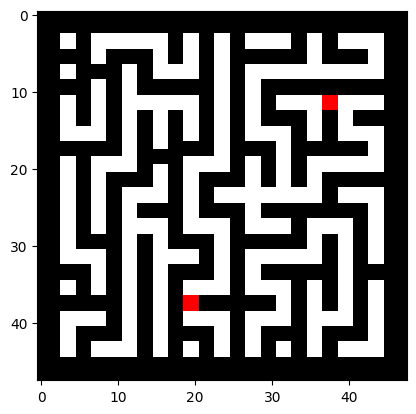

In [6]:
def visualize_maze(mazes, index):
    maze, maze_data = mazes[index]
    image = mazes.tensor_to_image(maze)
    plt.imshow(image)
    plt.show()
mazes = Mazes(maze_data_path)
visualize_maze(mazes, 7)

In [9]:
class MazeDataset(torch.utils.data.Dataset):
    def __init__(self, maze_data_path, transform=None):
        self.mazes = Mazes(maze_data_path)
        self.transform = transform
        
    def __len__(self):
        return len(self.mazes)
    
    def __getitem__(self, idx):
        maze, label = self.mazes[idx]
        if self.transform:
            maze = self.transform(maze)
        return maze, label

In [10]:
maze_dataset = MazeDataset(maze_data_path)
num_samples = 20000
if num_samples is None:
    num_samples = len(maze_dataset)
indices = torch.randperm(len(maze_dataset))[:num_samples].tolist()
maze_dataset = torch.utils.data.Subset(maze_dataset, indices)

# Split dataset into train and test sets
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size
train_dataset, test_dataset = torch.utils.data.random_split(maze_dataset, [train_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [2]:
# Define evaluation function
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, labels in data_loader:
            x = x.to(device)
            labels = labels.to(device)
            
            logits = model(x, num_steps=num_steps)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    model.train()
    return avg_loss, accuracy

def plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    clear_output(wait=True)
    
    # Create a single figure with all metrics
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    
    # Training metrics
    axs[0, 0].plot(train_losses, label='Training Loss')
    axs[0, 0].set_xlabel('Iteration')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].set_title('Training Loss')
    axs[0, 0].legend()
    
    axs[0, 1].plot(train_accuracies, label='Training Accuracy')
    axs[0, 1].set_xlabel('Iteration')
    axs[0, 1].set_ylabel('Accuracy')
    axs[0, 1].set_title('Training Accuracy')
    axs[0, 1].legend()
    
    # Validation metrics
    axs[1, 0].plot(val_losses, label='Validation Loss')
    axs[1, 0].set_xlabel('Iteration')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].set_title('Validation Loss')
    axs[1, 0].legend()
    
    axs[1, 1].plot(val_accuracies, label='Validation Accuracy')
    axs[1, 1].set_xlabel('Iteration')
    axs[1, 1].set_ylabel('Accuracy')
    axs[1, 1].set_title('Validation Accuracy')
    axs[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

# Define the training loop



model.train()
n_epochs = 500
train_log_frequency = len(train_loader) #max(len(train_loader) // 10, 1)  # How often to log training metrics
evaluate_frequency = len(train_loader) # How often to evaluate on validation set
print(len(train_loader))

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

plt.ion()  # turn on interactive mode

running_loss, running_correct, running_total = 0, 0, 0
for epoch in range(n_epochs):
    for i, (x, labels) in enumerate(tqdm(train_loader)):
        x = x.to(device)
        labels = labels.to(device)
        torch._inductor.cudagraph_mark_step_begin()
        logits = model(x, num_steps=num_steps)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate running accuracy and loss
        _, predicted = torch.max(logits, 1)
        running_total += labels.size(0)
        running_correct += (predicted == labels).sum().item()
        running_loss += loss.item()

        # Log training metrics
        if (i + 1) % train_log_frequency == 0:
            print(
                f"Training | Epoch: {epoch} | "
                + f"Loss: {running_loss / running_total:.4f} | "
                + f"Acc: {running_correct / running_total:.2%}"
            )
            
            train_losses.append(running_loss / running_total)
            train_accuracies.append(running_correct / running_total)
            running_loss, running_correct, running_total = 0, 0, 0
            plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

        # Evaluate on validation set
        if (i + 1) % evaluate_frequency == 0:
            val_loss, val_acc = evaluate(model, test_loader, criterion, device)
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)
            plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

NameError: name 'model' is not defined

In [2]:
import numpy as np
import torch
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm
import os
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output
import wandb
import psutil
import GPUtil
wandb.login(key="a338f755915cccd861b14f29bf68601d8e1ec2c9")

from bioplnn.models import SpatiallyEmbeddedClassifier
from bioplnn.datasets import Mazes

maze_data_path = "/om2/user/jackking/torch-bioplnn-dev/data/mazes"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

BATCH_SIZE = 32

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, num_steps=None):  # num_steps parameter for compatibility
        # x shape: [batch_size, channels, height, width]
        x = self.pool(self.relu(self.conv1(x)))  # -> [batch_size, 32, 24, 24]
        x = self.pool(self.relu(self.conv2(x)))  # -> [batch_size, 64, 12, 12]
        x = self.pool(self.relu(self.conv3(x)))  # -> [batch_size, 128, 6, 6]
        x = x.view(-1, 128 * 6 * 6)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class MazeDataset(torch.utils.data.Dataset):
    def __init__(self, maze_data_path, transform=None):
        self.mazes = Mazes(maze_data_path)
        self.transform = transform
        
    def __len__(self):
        return len(self.mazes)
    
    def __getitem__(self, idx):
        maze, label = self.mazes[idx]
        print(maze.shape)
        maze = torch.stack([maze[0], maze[-1]])
        print(maze.shape)
        if self.transform:
            maze = self.transform(maze)
        return maze, label

def load_data(batch_size=BATCH_SIZE, num_samples=None):
    # Create the dataset
    maze_dataset = MazeDataset(maze_data_path)
    if num_samples is None:
        num_samples = len(maze_dataset)
    indices = torch.randperm(len(maze_dataset))[:num_samples].tolist()
    maze_dataset = torch.utils.data.Subset(maze_dataset, indices)
    input, label = maze_dataset[0]
    print(label)
    plt.imshow(input[0].numpy() + input[1].numpy())

load_data()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jackking/.netrc


torch.Size([4, 48, 48])


TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

In [3]:
data = Mazes(maze_data_path)

In [11]:
len(data[0][0])

4